PowBlock class

In [ ]:
"""COMP842 - Exercise 2: Proof of Work (SHA-256) - mining, difficulty & probability."""

import hashlib
import statistics
import time

import pandas as pd


class PowBlock:
    """A block that must be mined: its hash has to start with `difficulty` zeros."""

    def __init__(self, index, data, previous_hash):
        self.index = index
        self.timestamp = time.time()
        self.data = data
        self.previous_hash = previous_hash
        self.nonce = 0
        self.hash = None
        # Header fields never change while mining, so build the prefix once.
        # Only the nonce is appended on each attempt -> keeps the hot loop fast.
        self._prefix = f"{index}|{self.timestamp}|{data}|{previous_hash}|".encode()

    def compute_hash(self, nonce=None):
        n = self.nonce if nonce is None else nonce
        return hashlib.sha256(self._prefix + str(n).encode()).hexdigest()

    def mine(self, difficulty):
        """Increment the nonce until the hash starts with `difficulty` zeros.
        Returns (attempts, seconds)."""
        target = "0" * difficulty
        sha256 = hashlib.sha256          # local alias: avoids attribute lookup per attempt
        prefix = self._prefix
        nonce = 0

        start = time.perf_counter()
        while True:
            h = sha256(prefix + str(nonce).encode()).hexdigest()
            if h.startswith(target):
                break
            nonce += 1
        elapsed = time.perf_counter() - start

        self.nonce, self.hash = nonce, h
        return nonce + 1, elapsed        # nonce starts at 0, so attempts = nonce + 1

    def is_valid(self, difficulty):
        # Anyone can verify with ONE hash - cheap to check, expensive to produce
        return self.hash == self.compute_hash() and self.hash.startswith("0" * difficulty)

MiningExperiment

In [ ]:
class MiningExperiment:
    """Mines N blocks per difficulty level and records time + attempts for each."""

    def __init__(self, difficulties, blocks_per_level=30):
        self._difficulties = difficulties
        self._blocks_per_level = blocks_per_level
        self._records = []               # one dict per mined block

    def run(self):
        for d in self._difficulties:
            print(f"\n{'=' * 30} DIFFICULTY {d} ({'0' * d}...) {'=' * 30}")
            print(f"{'Block':>5} {'Nonce':>9} {'Attempts':>9} {'Time (ms)':>10}  Valid hash")
            previous_hash = "0" * 64     # each difficulty level is its own small chain

            for i in range(1, self._blocks_per_level + 1):
                block = PowBlock(i, f"D{d}-Block{i}: Alice pays Bob {i} coins", previous_hash)
                attempts, seconds = block.mine(d)
                assert block.is_valid(d), "mined block failed verification"

                self._records.append({"difficulty": d, "block": i, "nonce": block.nonce,
                                      "attempts": attempts, "time_s": seconds, "hash": block.hash})
                print(f"{i:>5} {block.nonce:>9} {attempts:>9} {seconds * 1000:>10.3f}  {block.hash}")
                previous_hash = block.hash

            level = [r for r in self._records if r["difficulty"] == d]
            avg_ms = statistics.mean(r["time_s"] for r in level) * 1000
            avg_att = statistics.mean(r["attempts"] for r in level)
            print(f"-> Difficulty {d}: average time = {avg_ms:.3f} ms, "
                  f"average attempts = {avg_att:,.1f} (theoretical {16 ** d:,})")

    def summary(self):
        """Performance metrics per difficulty, incl. theoretical vs measured attempts."""
        rows = []
        for d in self._difficulties:
            level = [r for r in self._records if r["difficulty"] == d]
            times = [r["time_s"] for r in level]
            attempts = [r["attempts"] for r in level]
            theoretical = 16 ** d        # P(one hash has d leading hex zeros) = 1/16^d
            rows.append({
                "Difficulty": d,
                "Avg time (s)": statistics.mean(times),
                "Min time (s)": min(times),
                "Max time (s)": max(times),
                "Std dev (s)": statistics.stdev(times),          # sample std dev
                "Throughput (H/s)": sum(attempts) / sum(times),  # total hashes / total time
                "Measured avg attempts": statistics.mean(attempts),
                "Theoretical (16^d)": theoretical,
                "Measured / Theoretical": statistics.mean(attempts) / theoretical,
            })
        return pd.DataFrame(rows).set_index("Difficulty")

    def growth(self):
        """Ratio between consecutive difficulty levels (~16x means exponential growth)."""
        s = self.summary()
        rows = []
        for a, b in zip(self._difficulties, self._difficulties[1:]):
            rows.append({
                "Step": f"{a} -> {b}",
                "Avg time ratio": s.loc[b, "Avg time (s)"] / s.loc[a, "Avg time (s)"],
                "Avg attempts ratio": s.loc[b, "Measured avg attempts"] / s.loc[a, "Measured avg attempts"],
                "Expected ratio": 16,
            })
        return pd.DataFrame(rows).set_index("Step")

Run the experiment

In [ ]:
experiment = MiningExperiment(difficulties=[2, 3, 4, 5], blocks_per_level=30)
experiment.run()


============================== DIFFICULTY 2 (00...) ==============================
Block     Nonce  Attempts  Time (ms)  Valid hash
    1       234       235      0.192  003d21de1faeebb54bc9695f441017549016d882a88a624722de0f510063acaf
    2       233       234      0.185  00165574471b2e8edafc85ee629661f14b918223c67f722b81c4c78bba94f891
    3       116       117      0.133  0071d39f8b1b2f314793c18ee29a52f6744e65278b1e88dba09029ed678406cc
    4       435       436      0.380  0062bf1d26f3d62388c12ec626a7509d1e66d7333ba8fc3c04498298b814e093
    5       218       219      0.188  002243de3a177090844dd2c9a2c37c33f256975ab075369c9df73780f05e52ae
    6       271       272      0.199  00780a0c012ea392874d8cd0aef2694a6e5f13f423e1bcba175231fdee4dfc19
    7       336       337      0.237  0012cc596ed08b18849a4eda1ae609b776e8580f5026ea0e9e250040b7bfda9b
    8       568       569      0.477  00cb32175869265615b178764c2043310599f4cc93d1f2ab606d5ca1937a81f6
    9      1079      1080      0.784  001b5

Results tables

In [ ]:
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")
print("Table 2.1: Proof-of-Work performance metrics (30 blocks per difficulty)")
display(experiment.summary())

print("\nTable 2.2: Growth between difficulty levels")
display(experiment.growth())

Table 2.1: Proof-of-Work performance metrics (30 blocks per difficulty)


,Avg time (s),Min time (s),Max time (s),Std dev (s),Throughput (H/s),Measured avg attempts,Theoretical (16^d),Measured / Theoretical
Difficulty,,,,,,,,
2,0.000212,0.000003,0.000784,0.000173,"1,305,066.685964",276.766667,256,1.081120
3,0.003279,0.000175,0.009854,0.002429,"1,309,034.948558","4,292.466667",4096,1.047965
4,0.049570,0.001036,0.300921,0.065122,"1,330,886.617809","65,972.533333",65536,1.006661
5,1.342502,0.013754,6.399305,1.411066,"1,159,711.553336","1,556,915.200000",1048576,1.484790



Table 2.2: Growth between difficulty levels


,Avg time ratio,Avg attempts ratio,Expected ratio
Step,,,
2 -> 3,15.462318,15.509334,16
3 -> 4,15.117028,15.369376,16
4 -> 5,27.082757,23.599445,16


Chart (log scale)

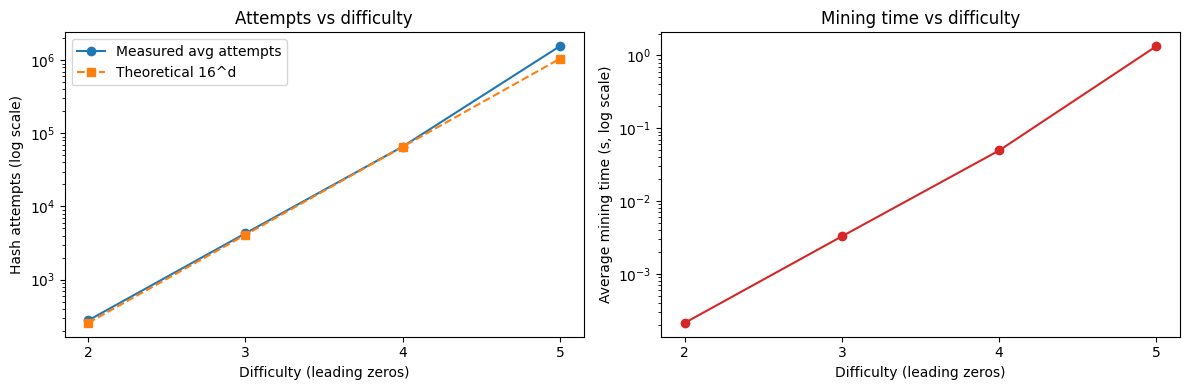

In [ ]:
import matplotlib.pyplot as plt

s = experiment.summary()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(s.index, s["Measured avg attempts"], "o-", label="Measured avg attempts")
ax1.plot(s.index, s["Theoretical (16^d)"], "s--", label="Theoretical 16^d")
ax1.set_yscale("log")                 # a straight line on a log scale = exponential growth
ax1.set_xlabel("Difficulty (leading zeros)")
ax1.set_ylabel("Hash attempts (log scale)")
ax1.set_title("Attempts vs difficulty")
ax1.set_xticks(s.index)
ax1.legend()

ax2.plot(s.index, s["Avg time (s)"], "o-", color="tab:red")
ax2.set_yscale("log")
ax2.set_xlabel("Difficulty (leading zeros)")
ax2.set_ylabel("Average mining time (s, log scale)")
ax2.set_title("Mining time vs difficulty")
ax2.set_xticks(s.index)

plt.tight_layout()
plt.show()